In [1]:
%pip install -U "transformers>=4.41" "datasets>=2.20" "accelerate>=0.33" "evaluate>=0.4" sentencepiece sacrebleu tqdm
!pip install sacremoses

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, random, numpy as np, torch, inspect
from datasets import load_dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
)
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True

# Project & run knobs (kept small/fast)
PROJECT_DIR = "./marian_bilingual_en_es_pt"
os.makedirs(PROJECT_DIR, exist_ok=True)

MAX_SAMPLES = 1200        # per split, per language direction (train subset)
EVAL_SAMPLES = 300        # validation slice for quick BLEU
MAX_SRC_LEN = 128
MAX_TGT_LEN = 128
BATCH = 8                 # lower to 4/2 if OOM
GRAD_ACCUM = 1
MAX_STEPS = 500           # short fine-tune; bump to 1500+ for quality

device = "cuda" if torch.cuda.is_available() else "cpu"
use_bf16 = torch.cuda.is_available() and getattr(torch.cuda, "is_bf16_supported", lambda: False)()
use_fp16 = torch.cuda.is_available() and not use_bf16
print(f"Device={device} | bf16={use_bf16} | fp16={use_fp16}")


Device=cuda | bf16=True | fp16=False


c:\Users\jeeva\anaconda3\Lib\site-packages\torch\__init__.py:1628: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:50.)
  _C._set_float32_matmul_precision(precision)


In [3]:
# --- EN→ES (Marian) ---
tok_es = AutoTokenizer.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es",
    token=None,               # force anonymous (ignore any stale tokens)
    local_files_only=False,   # allow fresh download if not cached
    use_fast=True
)
mod_es = AutoModelForSeq2SeqLM.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es",
    token=None,
    local_files_only=False
).to(device)

# --- EN→PT (Marian ONLY; no fallback) ---

# EN→PT (Marian) 
# -----------------------------------------
tok_pt = AutoTokenizer.from_pretrained(
    "Helsinki-NLP/opus-mt-tc-big-en-pt",
    token=None,
    local_files_only=False,
    use_fast=True
)
mod_pt = AutoModelForSeq2SeqLM.from_pretrained(
    "Helsinki-NLP/opus-mt-tc-big-en-pt",
    token=None,
    local_files_only=False
).to(device)

assert getattr(mod_pt.config, "model_type", "") == "marian", \
    f"Unexpected PT model type: {getattr(mod_pt.config, 'model_type', '?')}"
print("✅ Loaded EN→PT (Marian) from mirror")



✅ Loaded EN→PT (Marian) from mirror


In [4]:
GLOSSARY = {
    "polymerase chain reaction": {"es": "reacción en cadena de la polimerasa", "pt": "reação em cadeia da polimerase"},
    "confidence interval": {"es": "intervalo de confianza", "pt": "intervalo de confiança"},
}
def apply_glossary(text: str, lang: str) -> str:
    out = text
    for en_term, mapping in GLOSSARY.items():
        if lang in mapping:
            out = out.replace(en_term, mapping[lang])
    return out


In [5]:
def load_small(pair: str, split: str, max_samples: int):
    """
    pair: 'en-es' or 'en-pt'
    returns Dataset with columns: src_text, tgt_text
    """
    ds = load_dataset("opus100", pair, split=split)
    ds = ds.select(range(min(max_samples, len(ds))))
    src_lang, tgt_lang = pair.split("-")
    def norm(ex):
        tr = ex.get("translation", {})
        return {"src_text": tr.get(src_lang, ex.get(src_lang)), "tgt_text": tr.get(tgt_lang, ex.get(tgt_lang))}
    return ds.map(norm, remove_columns=ds.column_names)

train_es = load_small("en-es", "train", MAX_SAMPLES)
valid_es = load_small("en-es", "validation", EVAL_SAMPLES)
train_pt = load_small("en-pt", "train", MAX_SAMPLES)
valid_pt = load_small("en-pt", "validation", EVAL_SAMPLES)

print("Train sizes  EN→ES / EN→PT:", len(train_es), len(train_pt))
print("Valid sizes  EN→ES / EN→PT:", len(valid_es), len(valid_pt))


Train sizes  EN→ES / EN→PT: 1200 1200
Valid sizes  EN→ES / EN→PT: 300 300


In [6]:
def preprocess_any(batch, tok, tgt_short: str):
    # Apply your glossary to targets
    targets = [apply_glossary(t, tgt_short) for t in batch["tgt_text"]]

    # Encode source (Marian: no src/tgt lang flags needed)
    model_inputs = tok(
        batch["src_text"],
        truncation=True,
        max_length=MAX_SRC_LEN,
    )

    # Encode labels (HF>=4.27 supports text_target; keep fallback for older versions)
    try:
        labels = tok(
            text_target=targets,
            truncation=True,
            max_length=MAX_TGT_LEN,
        )
    except TypeError:
        from contextlib import contextmanager
        cm = tok.as_target_tokenizer() if hasattr(tok, "as_target_tokenizer") else contextmanager(lambda: (yield))()
        with cm:
            labels = tok(
                targets,
                truncation=True,
                max_length=MAX_TGT_LEN,
            )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Rebuild tokenized datasets (no NLLB language setting needed)
train_es_tok = train_es.map(lambda b: preprocess_any(b, tok_es, "es"),
                            batched=True, remove_columns=train_es.column_names)
valid_es_tok = valid_es.map(lambda b: preprocess_any(b, tok_es, "es"),
                            batched=True, remove_columns=valid_es.column_names)

train_pt_tok = train_pt.map(lambda b: preprocess_any(b, tok_pt, "pt"),
                            batched=True, remove_columns=train_pt.column_names)
valid_pt_tok = valid_pt.map(lambda b: preprocess_any(b, tok_pt, "pt"),
                            batched=True, remove_columns=valid_pt.column_names)

print("✅ Tokenization done (ES & PT).")


✅ Tokenization done (ES & PT).


In [7]:
bleu = evaluate.load("sacrebleu")

def compute_metrics_for(tok):
    def _inner(eval_pred):
        preds, labels = eval_pred
        # decode preds
        decoded_preds = tok.batch_decode(preds, skip_special_tokens=True)
        # replace -100 in labels then decode
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        decoded_labels = tok.batch_decode(labels, skip_special_tokens=True)
        return {"bleu": bleu.compute(predictions=decoded_preds, references=[[l] for l in decoded_labels])["score"]}
    return _inner

def make_training_args(**wanted):
    # filter kwargs to support older transformers
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    filtered = {k: v for k, v in wanted.items() if k in accepted}
    dropped = sorted(set(wanted) - set(filtered))
    if dropped: print("Dropped unsupported keys:", dropped)
    return TrainingArguments(**filtered)


In [8]:
# === Self-healing EN→ES trainer ===
import inspect, torch
from transformers import TrainingArguments, DataCollatorForSeq2Seq, Trainer


# ---- Build/rebuild collator ----
collator_es = DataCollatorForSeq2Seq(
    tokenizer=tok_es,
    model=mod_es,
    padding="longest",               # or pad_to_multiple_of=8 for GPU speed
)

# ---- Version-agnostic TrainingArguments (filters unknown kwargs) ----
def make_training_args(**wanted):
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    filtered = {k: v for k, v in wanted.items() if k in accepted}
    return TrainingArguments(**filtered)

args_es = make_training_args(
    output_dir=f"{PROJECT_DIR}/ckpt_es",
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=3e-5,
    lr_scheduler_type="linear",    # ignored if unsupported by your version
    warmup_ratio=0.05,             # ignored if unsupported
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
    no_cuda=(device != "cuda"),
    dataloader_num_workers=0,      # safe on Windows
    dataloader_pin_memory=(device == "cuda"),
    evaluation_strategy="no",      # ignored if unsupported
    save_strategy="no",            # ignored if unsupported
)

# ---- Build trainer ----
trainer_es = Trainer(
    model=mod_es,
    args=args_es,
    train_dataset=train_es_tok,
    eval_dataset=None,             # eval later in a separate cell
    data_collator=collator_es,
    tokenizer=tok_es,
)

print("✅ EN→ES trainer ready. Starting training…")
train_output = trainer_es.train()
print("✅ EN→ES done.")


C:\Users\jeeva\AppData\Local\Temp\ipykernel_19736\1402396033.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_es = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


✅ EN→ES trainer ready. Starting training…


Step,Training Loss
50,1.069400
100,1.001900
150,1.057000
200,0.778100
250,0.658300
300,0.611500
350,0.512000
400,0.550700
450,0.519100
500,0.426700


✅ EN→ES done.


In [14]:
# === Self-healing EN→PT trainer ===
import inspect, torch
from transformers import TrainingArguments, DataCollatorForSeq2Seq, Trainer

# ---- Build/rebuild collator ----
collator_pt = DataCollatorForSeq2Seq(
    tokenizer=tok_pt,
    model=mod_pt,
    padding="longest",               # or pad_to_multiple_of=8 for GPU speed
)



args_pt = make_training_args(
    output_dir=f"{PROJECT_DIR}/ckpt_pt",
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=3e-5,
    lr_scheduler_type="linear",      # ignored if unsupported by your version
    warmup_ratio=0.05,               # ignored if unsupported
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
    no_cuda=(device != "cuda"),
    dataloader_num_workers=0,        # safe on Windows
    dataloader_pin_memory=(device == "cuda"),
    evaluation_strategy="no",        # ignored if unsupported
    save_strategy="no",              # ignored if unsupported
)

# ---- Build trainer ----
trainer_pt = Trainer(
    model=mod_pt,
    args=args_pt,
    train_dataset=train_pt_tok,
    eval_dataset=None,               # eval later in a separate cell
    data_collator=collator_pt,
    tokenizer=tok_pt,
)

print("✅ EN→PT trainer ready. Starting training…")
train_output_pt = trainer_pt.train()
print("✅ EN→PT done.")


C:\Users\jeeva\AppData\Local\Temp\ipykernel_19736\1984454602.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_pt = Trainer(


✅ EN→PT trainer ready. Starting training…


Step,Training Loss
50,0.598300
100,0.542100
150,0.987900
200,0.519400
250,0.496400
300,0.428900
350,0.274900
400,0.314400
450,0.325300
500,0.248800


✅ EN→PT done.


In [15]:
# === Accuracy/quality evaluation for EN→ES and EN→PT ===
import torch, numpy as np, evaluate

# Config
EVAL_LIMIT   = 300          # evaluate on up to N examples
MAX_NEW_TOK  = 64
MIN_NEW_TOK  = 3
NUM_BEAMS    = 4
BATCH_SIZE   = 32

bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")

@torch.inference_mode()
def batch_generate(model, tok, texts, max_len_src=128, max_new=MAX_NEW_TOK, beams=NUM_BEAMS, batch_size=BATCH_SIZE):
    enc = tok(texts, return_tensors="pt", padding=True, truncation=True, max_length=max_len_src)
    input_ids = enc["input_ids"]
    attn = enc.get("attention_mask")
    preds = []
    for i in range(0, input_ids.size(0), batch_size):
        sl = slice(i, i + batch_size)
        batch = {"input_ids": input_ids[sl].to(model.device)}
        if attn is not None:
            batch["attention_mask"] = attn[sl].to(model.device)
        out = model.generate(
            **batch,
            max_new_tokens=max_new,
            min_new_tokens=MIN_NEW_TOK,
            num_beams=beams,
            no_repeat_ngram_size=3,
            length_penalty=1.0,
            do_sample=False,
        )
        preds.extend(tok.batch_decode(out, skip_special_tokens=True))
    return [p.strip() for p in preds]

def evaluate_pair(model, tok, valid_ds, lang_name="ES"):
    # Slice evaluation set
    src = [r["src_text"] for r in valid_ds][:EVAL_LIMIT]
    refs = [r["tgt_text"] for r in valid_ds][:EVAL_LIMIT]

    # Generate predictions
    preds = batch_generate(model, tok, src, max_len_src=MAX_SRC_LEN)

    # Metrics
    refs_bleu = [[r] for r in refs]  # sacrebleu expects list[list[str]]
    bleu = bleu_metric.compute(predictions=preds, references=refs_bleu)["score"]
    chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)["score"]

    # Exact-match accuracy (strict string equality)
    exact = np.mean([int(p == r) for p, r in zip(preds, refs)]) * 100.0

    # Print a few samples
    k = min(3, len(preds))
    print(f"\n--- {lang_name} samples ---")
    for i in range(k):
        print("SRC:", src[i])
        print("PRD:", preds[i])
        print("REF:", refs[i])
        print("---")

    print(f"{lang_name} -> Metrics on {len(preds)} examples:")
    print(f"  BLEU : {bleu:.2f}")
    print(f"  chrF : {chrf:.2f}")
    print(f"  Exact-match accuracy : {exact:.2f}%")
    return {"bleu": bleu, "chrf": chrf, "exact_acc": exact}

# Evaluate both models if available
results = {}
if 'mod_es' in globals() and 'tok_es' in globals() and 'valid_es' in globals():
    results["es"] = evaluate_pair(mod_es, tok_es, valid_es, lang_name="EN→ES")
if 'mod_pt' in globals() and 'tok_pt' in globals() and 'valid_pt' in globals():
    results["pt"] = evaluate_pair(mod_pt, tok_pt, valid_pt, lang_name="EN→PT")

results



--- EN→ES samples ---
SRC: I don't even remember what the fight was about.
PRD: Ni siquiera recuerdo de qué se trataba la pelea.
REF: No recuerdo por qué fue la pelea.
---
SRC: Here are the sites of each of those that have taken place:
PRD: Aquí están los sitios de cada uno de los que han tenido lugar:
REF: Estos son los sitios en que cada Congreso ha tenido lugar:
---
SRC: I'm the man who killed Blackbeard.
PRD: Soy el hombre que mató a Barbanegra.
REF: Sí. Soy el hombre que mató a Barbanegra.
---
EN→ES -> Metrics on 300 examples:
  BLEU : 39.68
  chrF : 59.89
  Exact-match accuracy : 10.33%

--- EN→PT samples ---
SRC: He's never done anything.
PRD: Ele nunca fez nada.
REF: Nunca fez nada.
---
SRC: 50/50 shot?
PRD: Um tiro de 50/50?
REF: 50/50 de hipóteses?
---
SRC: Yeah, and I'm letting you get your come-up. But you gonna be good?
PRD: Sim, e vou deixar que arranjes a tua opinião, mas vais ficar bem?
REF: Deixo que os enfrentes, mas vais portar-te bem?
---
EN→PT -> Metrics on 300 ex

{'es': {'bleu': 39.68265936009402,
  'chrf': 59.894724432021775,
  'exact_acc': np.float64(10.333333333333334)},
 'pt': {'bleu': 36.99362942319139,
  'chrf': 60.28270765033482,
  'exact_acc': np.float64(5.666666666666666)}}

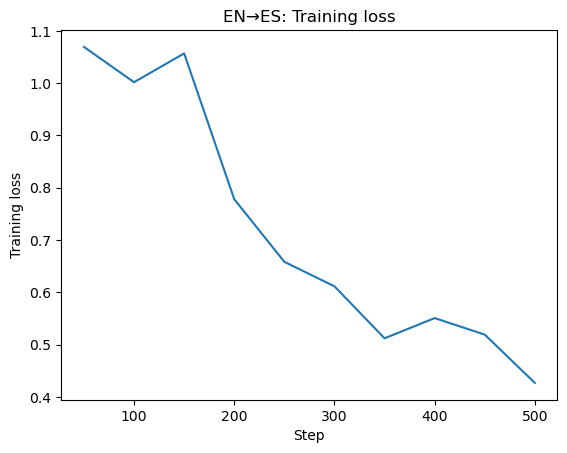

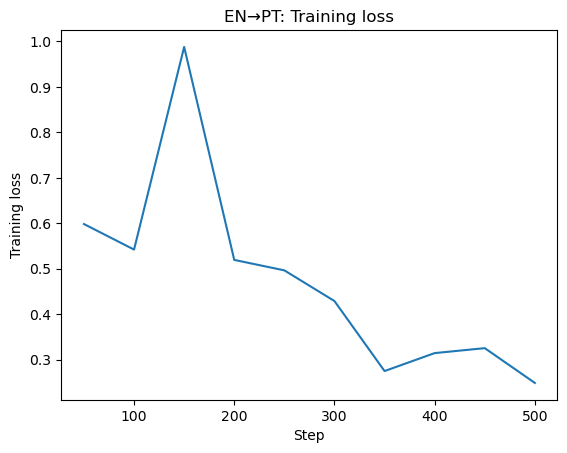

In [16]:
def plot_loss(trainer, title):
    loss_points = [(e["step"], e["loss"]) for e in getattr(trainer.state, "log_history", []) if "loss" in e]
    if not loss_points:
        print(f"{title}: no loss logs found (set logging_steps > 0).")
        return
    steps, losses = zip(*loss_points)
    plt.figure()
    plt.plot(steps, losses)
    plt.xlabel("Step"); plt.ylabel("Training loss"); plt.title(title); plt.show()

plot_loss(trainer_es, "EN→ES: Training loss")
plot_loss(trainer_pt, "EN→PT: Training loss")


In [18]:
def translate_es(text, max_new_tokens=128, num_beams=5):
    enc = tok_es([text], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        out = mod_es.generate(**enc, num_beams=num_beams, max_new_tokens=max_new_tokens, no_repeat_ngram_size=3, early_stopping=True)
    return tok_es.batch_decode(out, skip_special_tokens=True)[0]

def translate_pt(text, max_new_tokens=128, num_beams=5):
    enc = tok_pt([text], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        out = mod_pt.generate(**enc, num_beams=num_beams, max_new_tokens=max_new_tokens, no_repeat_ngram_size=3, early_stopping=True)
    return tok_pt.batch_decode(out, skip_special_tokens=True)[0]

print(translate_es("hello how are u"
"."))
print(translate_pt("HI."))


Hola, ¿cómo estás?
Olá.
